In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential

from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

In [6]:
# Load Data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)

(60000, 28, 28)


In [8]:
# Preprocessing of data : only deals with x
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [13]:
# Model Creation
model = Sequential()

model.add(
    Conv2D(
         32,
        (3,3),
        activation= 'relu',
        input_shape= (28, 28, 1)
    )
)
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation= 'relu'))
model.add(Dense(10, activation= 'softmax'))


In [17]:
# Compile Model
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [18]:
# Train Model
model.fit(
    X_train,
    y_train,
    epochs = 5,
    validation_data = (X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.6630 - loss: 0.9414 - val_accuracy: 0.7460 - val_loss: 0.6468
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.7861 - loss: 0.5744 - val_accuracy: 0.7993 - val_loss: 0.5508
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.8176 - loss: 0.5045 - val_accuracy: 0.8175 - val_loss: 0.5053
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.8349 - loss: 0.4653 - val_accuracy: 0.8240 - val_loss: 0.4800
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - accuracy: 0.8451 - loss: 0.4381 - val_accuracy: 0.8333 - val_loss: 0.4607


In [19]:
# Evaluation of Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8333 - loss: 0.4607
Accuracy:  0.833299994468689


In [28]:
# Predicting Cloth Categories
class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

prediction = model.predict(X_test[:10])
prediction_label = np.argmax(prediction, axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


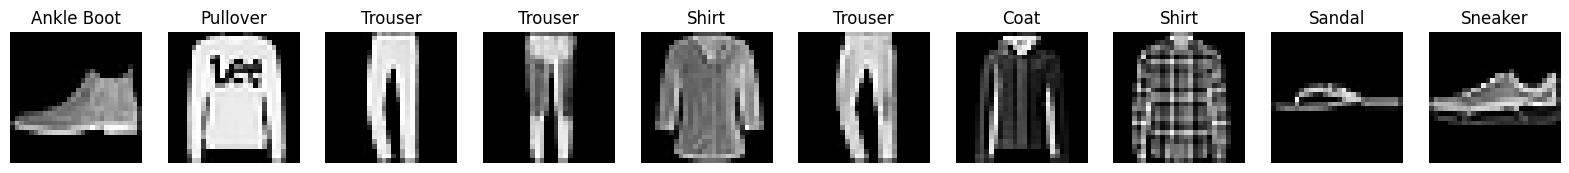

In [29]:
plt.figure(figsize=(20,10))

for i in range(10):

  plt.subplot(1, 10, i+1)

  plt.imshow(
      X_test[i].reshape(28,28),
      cmap= 'gray'
  )

  plt.title(class_names[prediction_label[i]])

  plt.axis('off')

plt.show()